# 05 · V9 — the final richer-deviations composite (strict-gate blend)

V9 builds V6 (roofing), V7 (breadth), V8 (change-point), runs each through the **strict OOS gate**
vs the V0 baseline, and blends **only the survivors** (rank / robust-z average). `gate='report_only'`
blends all and shows the scorecard for comparison. V0's 3y-z is kept as the slow *context* band.

In [1]:
import sys, os
# Make the notebook self-sufficient: walk up from cwd to the repo root (dir containing `positioning`).
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "positioning")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
ORANGE="#FF8200"; GREY="#3C3C3C"; BLUE="#1F4E79"; RED="#C00000"; GREEN="#2E7D32"; PURPLE="#7030A0"; TEAL="#0F9D9D"

from positioning.versions import base, compare, richness, dsp, transforms
from positioning.versions import params as P
from positioning.versions.base import responsiveness

def show(df, n=None):
    """Render a DataFrame/dict, truncated."""
    try:
        display(df if n is None else df.head(n))
    except Exception:
        print(df)

def zline(ax, bounded=False):
    """Draw crowd bands for a composite axis."""
    if bounded:
        ax.axhline(80, color=RED, ls="--", lw=0.7); ax.axhline(20, color=GREEN, ls="--", lw=0.7)
    else:
        for k in (1.5, -1.5): ax.axhline(k, color=GREY, ls="--", lw=0.6)
        ax.axhline(0, color=GREY, lw=0.4)

def crossings(z, level=0.0):
    """Count sign changes of (z-level): a proxy for 'deviations per unit time'."""
    s = z.dropna().astype(float) - level
    return int((np.sign(s).diff().abs() > 0).sum())

print("loaded versions package — building shared inputs (cache-first)…")
inp = base.load_inputs()
y10 = inp.y10_w
print(f"inputs: {len(inp.report_dates)} weekly dates {inp.report_dates.min().date()}..{inp.report_dates.max().date()}")

loaded versions package — building shared inputs (cache-first)…


inputs: 422 weekly dates 2018-06-19..2026-07-14


## Build V9 and see which components survived the gate

In [2]:
inp, results = compare.build_all()
r9 = results["v9"]; c9 = r9.composite.dropna()
print(r9.name); print(r9.description)
print("survivors / gate detail (meta):")
for k, v in r9.meta.items():
    print(f"  {k}: {str(v)[:100]}")

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


V9 Final richer-deviations composite
Strict-OOS-gated blend of the surviving V6/V7/V8 components (rank/robust-z/equal); keeps V0 as the slow context band. Reports which components' incremental deviations passed the gate; honest when none do.
survivors / gate detail (meta):
  components: ['v6', 'v7', 'v8']
  survivors: []
  gate_mode: strict
  gate_certified: False
  blend: rank
  horizon: 8
  gate: {'v6': {'pass': False, 'incremental_ic': -0.6496113477647727, 'surrogate_p': 0.11855670103092783, 'c
  latest: -0.170940170940171
  n_finite: 371
  note: Strict-gate blend of ['v6', 'v7', 'v8']. survivors=NONE — no component cleared the strict OOS gate o


## Full scorecard across V0–V9

In [3]:
allkeys = [k for k in ["v0","v1","v2","v3","v4","v5","v6","v7","v8","v9"] if k in results]
sc = richness.scorecard({k: results[k] for k in allkeys}, inp.y10_w, baseline_key="v0")
show(sc.round(3))

,cross0_per_yr,cross1_per_yr,cross2_per_yr,turns_per_yr,bienayme_z,half_life_wk,spectral_entropy,ic_8w,ic_t_8w,incr_ic,surrogate_p,cpcv_ic,gate_pass
v0,6.209,7.567,4.269,33.955,-0.339,4.567,0.520,0.163,0.692,NaN,NaN,NaN,False
v1,1.355,1.602,0.493,26.123,-7.868,414.106,0.195,0.139,NaN,-0.291,0.222,0.114,False
v2,2.620,7.859,0.000,23.970,-9.584,18.080,0.371,-0.027,-0.065,-0.374,0.160,-0.163,False
v3,5.281,5.281,1.490,25.729,-7.845,10.651,0.525,-0.093,-0.286,-0.645,0.057,-0.227,False
v4,4.715,11.919,1.310,27.244,-6.602,8.330,0.590,0.026,0.101,-0.061,0.853,-0.005,False
v5,23.325,23.539,7.276,36.593,1.578,0.663,0.879,-0.038,-0.585,-0.374,0.010,-0.021,False
v6,4.313,6.900,0.739,9.118,-23.835,16.992,0.595,-0.117,-0.299,-0.650,0.119,-0.129,False
v7,12.574,8.776,1.441,24.363,-9.226,4.069,0.728,-0.018,-0.102,NaN,NaN,-0.064,False
v8,13.360,13.098,0.000,27.113,-6.721,1.595,0.825,-0.047,-0.471,-0.259,0.445,-0.006,False
v9,11.914,9.951,1.822,22.005,-10.986,2.937,0.759,-0.198,-1.344,-0.605,0.010,-0.183,False


## V9 vs V0 — richer, and (by construction) only where informative

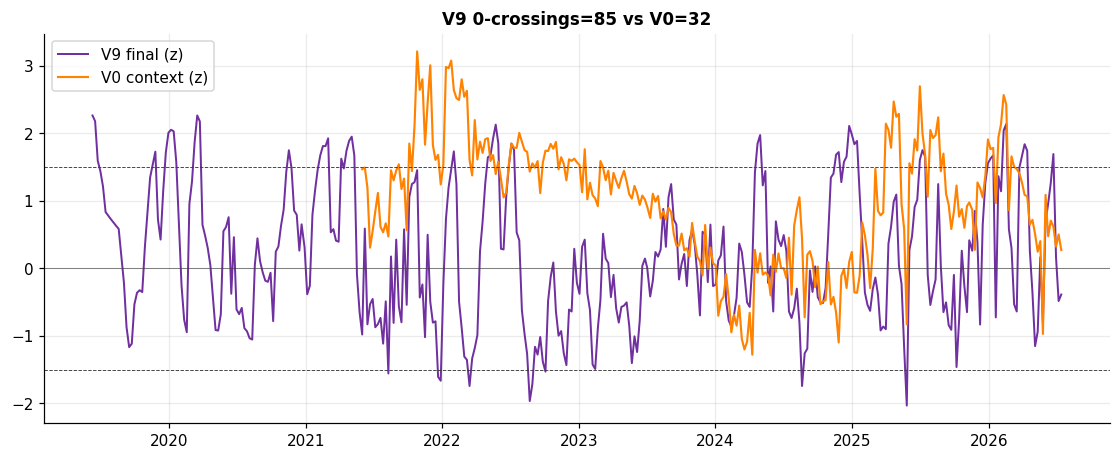

In [4]:
v0 = results["v0"].composite.dropna()
fig, ax = plt.subplots(figsize=(12.5, 4.6))
ax.plot(c9.index, richness.to_z(c9, r9.bounded), color=PURPLE, lw=1.3, label="V9 final (z)")
ax.plot(v0.index, richness.to_z(v0, False), color=ORANGE, lw=1.4, label="V0 context (z)")
zline(ax); ax.legend(loc="upper left")
ax.set_title(f"V9 0-crossings={crossings(richness.to_z(c9, r9.bounded))} vs V0={crossings(richness.to_z(v0, False))}")
display(fig); plt.close(fig)

## Final efficient frontier

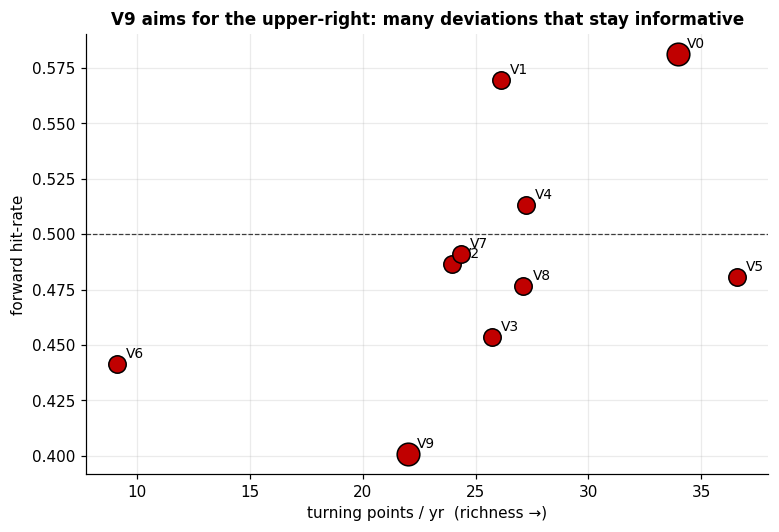

,version,turns_per_yr,hit_rate,gate_pass
0,v0,33.955,0.581,False
1,v1,26.123,0.570,False
2,v2,23.970,0.486,False
3,v3,25.729,0.454,False
4,v4,27.244,0.513,False
5,v5,36.593,0.481,False
6,v6,9.118,0.442,False
7,v7,24.363,0.491,False
8,v8,27.113,0.477,False
9,v9,22.005,0.401,False


In [5]:
try:
    fr = richness.frontier(sc)
    fig, ax = plt.subplots(figsize=(8, 5.2))
    for _, row in fr.iterrows():
        passed = bool(row.get("gate_pass", False))
        big = str(row["version"]) in ("v9","v0")
        ax.scatter(row["turns_per_yr"], row["hit_rate"], s=(220 if big else 130),
                   color=(GREEN if passed else RED), edgecolor="k", zorder=3)
        ax.annotate(str(row["version"]).upper(), (row["turns_per_yr"], row["hit_rate"]),
                    xytext=(6,4), textcoords="offset points", fontsize=9)
    ax.axhline(0.5, color=GREY, ls="--", lw=0.8)
    ax.set_xlabel("turning points / yr  (richness →)"); ax.set_ylabel("forward hit-rate")
    ax.set_title("V9 aims for the upper-right: many deviations that stay informative")
    display(fig); plt.close(fig)
    show(fr.round(3))
except Exception as e:
    print("frontier:", type(e).__name__, e)

## Recommendation & honesty note
The strict gate is deliberately conservative on a short (~8y), autocorrelated weekly sample — several
candidates are expected to fail, and that failure is reported, not hidden. V9 is the blend of whatever
components' **incremental** deviations survived. Where nothing clears the gate at t>3, the honest read
is that the *richer* signals improve **timeliness/turn-density** (a real, usable property for a desk
monitor) even where the marginal forward-return edge is not statistically established on this sample —
and the roofing oscillator / breadth-diffusion remain the best fast **context** reads alongside V0.